In [190]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [191]:
df = pd.read_csv('../../data/raw/Life Expectancy Data.csv')
df.head()

,Country,Year,Status,Life_expectancy,Adult_Mortality,infant_deaths,Alcohol,percentage_expenditure,Hepatitis_B,Measles,BMI,under_five_deaths,Polio,Total_expenditure,Diphtheria,HIV_AIDS,GDP,Population,thinness _1_19_years,thinness_5_9_years,Income_composition_of_resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,19.1,83,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,18.6,86,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,18.1,89,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,17.6,93,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,17.2,97,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [192]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)

# 정보 확인
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life_expectancy                  2928 non-null   float64
 4   Adult_Mortality                  2928 non-null   float64
 5   infant_deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage_expenditure           2938 non-null   float64
 8   Hepatitis_B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2904 non-null   float64
 11  under_five_deaths                2938 non-null   int64  
 12  Polio               

In [193]:
# 컬럼명 앞뒤 공백 제거
df.columns = df.columns.str.strip()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life_expectancy                  2928 non-null   float64
 4   Adult_Mortality                  2928 non-null   float64
 5   infant_deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage_expenditure           2938 non-null   float64
 8   Hepatitis_B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10  BMI                              2904 non-null   float64
 11  under_five_deaths                2938 non-null   int64  
 12  Polio               

In [194]:
print("결측치 개수:\n", df.isnull().sum())

결측치 개수:
 Country                              0
Year                                 0
Status                               0
Life_expectancy                     10
Adult_Mortality                     10
infant_deaths                        0
Alcohol                            194
percentage_expenditure               0
Hepatitis_B                        553
Measles                              0
BMI                                 34
under_five_deaths                    0
Polio                               19
Total_expenditure                  226
Diphtheria                          19
HIV_AIDS                             0
GDP                                448
Population                         652
thinness _1_19_years                34
thinness_5_9_years                  34
Income_composition_of_resources    167
Schooling                          163
dtype: int64


In [195]:
# 필요없는 값 제거
df = df.drop(['percentage_expenditure', 'Total_expenditure', 'Population', 'Income_composition_of_resources'], axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Country               2938 non-null   object 
 1   Year                  2938 non-null   int64  
 2   Status                2938 non-null   object 
 3   Life_expectancy       2928 non-null   float64
 4   Adult_Mortality       2928 non-null   float64
 5   infant_deaths         2938 non-null   int64  
 6   Alcohol               2744 non-null   float64
 7   Hepatitis_B           2385 non-null   float64
 8   Measles               2938 non-null   int64  
 9   BMI                   2904 non-null   float64
 10  under_five_deaths     2938 non-null   int64  
 11  Polio                 2919 non-null   float64
 12  Diphtheria            2919 non-null   float64
 13  HIV_AIDS              2938 non-null   float64
 14  GDP                   2490 non-null   float64
 15  thinness _1_19_years 

# 한 나라의 모든 연도에서 column 4개 이상 비어있는 경우 제거

In [196]:
# 한 나라의 모든 연도가 비어있는 column이 4개 이상일 때
def check_empty_columns(group):
    # 특정 국가에서 모든 값이 NaN인 컬럼의 개수 계산
    empty_col_count = (group.isnull().sum() == len(group)).sum()
    return empty_col_count < 4

df = df.groupby('Country').filter(check_empty_columns)

print("결측치 개수:\n", df.isnull().sum())

결측치 개수:
 Country                   0
Year                      0
Status                    0
Life_expectancy           6
Adult_Mortality           6
infant_deaths             0
Alcohol                 178
Hepatitis_B             538
Measles                   0
BMI                      16
under_five_deaths         0
Polio                     8
Diphtheria                8
HIV_AIDS                  0
GDP                     436
thinness _1_19_years     16
thinness_5_9_years       16
Schooling               160
dtype: int64


In [197]:
df.shape

(2918, 18)

# BMI가 없는 나라 제거

In [198]:
df = df.groupby('Country').filter(lambda x: not x['BMI'].isnull().all())

# GDP 결측치 보강

In [199]:
gdp_df = pd.read_csv('../../data/raw/GDP.csv', skiprows=4)

gdp_df.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,Unnamed: 69
0,Aruba,ABW,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6767.559229,8244.045660,10056.261393,11507.217151,12187.536361,13233.990517,13892.605143,14700.959808,16055.287787,16548.717387,16620.954556,17750.009564,18828.087059,19216.197235,20681.023027,20740.132583,21307.248251,21949.485996,23700.631990,24171.837133,24845.658484,26736.308944,28171.909401,25134.771230,24093.140151,25712.384302,25119.665545,25813.571441,26129.839062,27458.220154,27441.550214,28440.041688,30082.158423,30645.890602,22759.807175,26749.329609,30975.998912,35718.753119,39498.594129,NaN
1,Africa Eastern and Southern,AFE,GDP per capita (current US$),NY.GDP.PCAP.CD,186.089204,186.909053,197.367547,225.400079,208.962717,226.836135,240.911794,243.773593,257.143823,281.578894,276.732924,294.814162,311.465053,389.729024,463.468775,479.078798,468.774522,518.358685,571.617317,634.448116,773.301205,777.627960,725.547511,732.345461,650.346841,554.221296,578.317452,664.791813,704.142066,728.243319,822.402999,864.174086,732.910915,709.323534,700.772126,766.522931,746.787335,767.399412,697.079415,670.424213,706.727261,625.827815,630.512328,815.432296,989.015464,1126.297323,1235.266608,1381.552597,1447.545754,1408.753467,1628.905248,1761.989261,1732.038021,1706.022744,1690.166792,1498.875240,1334.470500,1528.104224,1552.073722,1507.085600,1351.591669,1562.416175,1679.327622,1571.449189,1615.396356,NaN
2,Afghanistan,AFG,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,174.930991,138.706822,178.954088,198.871116,221.763654,254.184249,274.218554,376.223152,381.733238,452.053705,560.621505,606.694676,651.417134,637.087099,625.054942,565.569730,522.082216,525.469771,491.337221,496.602504,510.787063,356.496214,357.261153,413.757895,NaN,NaN
3,Africa Western and Central,AFW,GDP per capita (current US$),NY.GDP.PCAP.CD,121.936832,127.451040,133.823783,139.004980,148.545883,155.561897,162.107340,144.940804,146.186183,161.917968,218.672141,195.859987,230.068904,280.643967,368.294725,413.366170,480.447260,490.839577,523.781318,624.870707,763.011988,1328.793688,1164.188488,873.979407,738.545691,754.905547,582.885076,583.317520,563.117147,512.477735,593.024667,607.840414,567.153365,574.472939,580.008123,866.731606,1069.590240,1091.831529,1141.486651,523.797280,518.969226,532.972787,619.337335,697.481256,838.213392,999.770023,1234.641856,1405.880188,1666.520483,1453.495284,1662.633658,1844.054367,1941.118243,2131.606091,2221.350338,1860.727686,1630.039439,1574.230564,1720.140092,2216.385055,2030.861659,2112.794076,2138.473153,1841.855064,1411.337029,NaN
4,Angola,AGO,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,729.111965,657.982649,634.221467,636.832811,650.491094,772.468833,697.526602,770.101140,807.439628,907.747893,965.866840,881.919488,668.706017,449.727895,334.973590,404.294818,531.115367,521.702915,429.188127,392.725539,563.733796,533.586202,999.065856,1133.663320,1451.471179,2145.886211,2930.444286,3515.056790,4578.155265,3645.148466,4101.637156,5184.152691,5702.453063,5688.579162,5649.687625,3641.728939,2051.814621,2790.718869,2860.093648,2493.678844,1759.356199,2303.908127,3682.113151,2916.136633,2665.874448,NaN


In [200]:
gdp_null_info = df[df['GDP'].isnull()].groupby('Country')['Year'].count().reset_index()
gdp_null_info.columns = ['Country', 'Missing_Years_Count']

gdp_null_info

,Country,Missing_Years_Count
0,Bahamas,16
1,Bolivia (Plurinational State of),16
2,Congo,16
3,Czechia,16
4,Côte d'Ivoire,16
5,Democratic People's Republic of Korea,16
6,Democratic Republic of the Congo,16
7,Egypt,16
8,Eritrea,4
9,Gambia,16


In [201]:
null_gdp_countries = df[df['GDP'].isnull()]['Country'].unique()

print(len(null_gdp_countries))
print()
null_gdp_countries

33



array(['Bahamas', 'Bolivia (Plurinational State of)', "Côte d'Ivoire",
       'Congo', 'Czechia', "Democratic People's Republic of Korea",
       'Democratic Republic of the Congo', 'Egypt', 'Eritrea', 'Gambia',
       'Iran (Islamic Republic of)', 'Iraq', 'Kyrgyzstan',
       "Lao People's Democratic Republic", 'Libya',
       'Micronesia (Federated States of)', 'Papua New Guinea',
       'Republic of Korea', 'Republic of Moldova',
       'Saint Kitts and Nevis', 'Saint Lucia',
       'Saint Vincent and the Grenadines', 'Sao Tome and Principe',
       'Slovakia', 'Somalia', 'Syrian Arab Republic',
       'The former Yugoslav republic of Macedonia',
       'United Kingdom of Great Britain and Northern Ireland',
       'United Republic of Tanzania', 'United States of America',
       'Venezuela (Bolivarian Republic of)', 'Viet Nam', 'Yemen'],
      dtype=object)

In [202]:
search_results = []

for country in null_gdp_countries:
    # 해당 국가명이 포함된 월드뱅크의 국가명들을 검색 (대소문자 무시)
    match = gdp_df[gdp_df['Country Name'].str.contains(country.split('(')[0].strip(), case=False, na=False)]['Country Name'].unique()
    
    if len(match) > 0:
        search_results.append(f"기대수명 데이터: [{country}] -> 월드뱅크 후보: {list(match)}")
    else:
        search_results.append(f"기대수명 데이터: [{country}] -> 월드뱅크에서 찾을 수 없음")

# 결과 출력
for res in search_results:
    print(res)

기대수명 데이터: [Bahamas] -> 월드뱅크 후보: ['Bahamas, The']
기대수명 데이터: [Bolivia (Plurinational State of)] -> 월드뱅크 후보: ['Bolivia']
기대수명 데이터: [Côte d'Ivoire] -> 월드뱅크에서 찾을 수 없음
기대수명 데이터: [Congo] -> 월드뱅크 후보: ['Congo, Dem. Rep.', 'Congo, Rep.']
기대수명 데이터: [Czechia] -> 월드뱅크 후보: ['Czechia']
기대수명 데이터: [Democratic People's Republic of Korea] -> 월드뱅크에서 찾을 수 없음
기대수명 데이터: [Democratic Republic of the Congo] -> 월드뱅크에서 찾을 수 없음
기대수명 데이터: [Egypt] -> 월드뱅크 후보: ['Egypt, Arab Rep.']
기대수명 데이터: [Eritrea] -> 월드뱅크 후보: ['Eritrea']
기대수명 데이터: [Gambia] -> 월드뱅크 후보: ['Gambia, The']
기대수명 데이터: [Iran (Islamic Republic of)] -> 월드뱅크 후보: ['Iran, Islamic Rep.']
기대수명 데이터: [Iraq] -> 월드뱅크 후보: ['Iraq']
기대수명 데이터: [Kyrgyzstan] -> 월드뱅크에서 찾을 수 없음
기대수명 데이터: [Lao People's Democratic Republic] -> 월드뱅크에서 찾을 수 없음
기대수명 데이터: [Libya] -> 월드뱅크 후보: ['Libya']
기대수명 데이터: [Micronesia (Federated States of)] -> 월드뱅크 후보: ['Micronesia, Fed. Sts.']
기대수명 데이터: [Papua New Guinea] -> 월드뱅크 후보: ['Papua New Guinea']
기대수명 데이터: [Republic of Korea] -> 월드뱅크에서 찾을 수 없음
기대수명 데

In [203]:
#  병합을 위한 임시 매핑 사전 (df 이름 : 월드뱅크 이름)
# '찾을 수 없음'으로 나왔던 나라들도 월드뱅크 표준 명칭을 찾아 반영했습니다.
mapping_dict = {
    "Bahamas": "Bahamas, The",
    "Bolivia (Plurinational State of)": "Bolivia",
    "Côte d'Ivoire": "Cote d'Ivoire",
    "Congo": "Congo, Rep.", # 혹은 Congo, Dem. Rep. 확인 필요 (보통 Congo는 Rep.)
    "Democratic People's Republic of Korea": "Korea, Dem. People's Rep.",
    "Democratic Republic of the Congo": "Congo, Dem. Rep.",
    "Egypt": "Egypt, Arab Rep.",
    "Gambia": "Gambia, The",
    "Iran (Islamic Republic of)": "Iran, Islamic Rep.",
    "Kyrgyzstan": "Kyrgyz Republic",
    "Lao People's Democratic Republic": "Lao PDR",
    "Micronesia (Federated States of)": "Micronesia, Fed. Sts.",
    "Republic of Korea": "Korea, Rep.",
    "Republic of Moldova": "Moldova",
    "Saint Kitts and Nevis": "St. Kitts and Nevis",
    "Saint Lucia": "St. Lucia",
    "Saint Vincent and the Grenadines": "St. Vincent and the Grenadines",
    "Slovakia": "Slovak Republic",
    "Somalia": "Somalia, Fed. Rep.",
    "The former Yugoslav republic of Macedonia": "North Macedonia",
    "United Republic of Tanzania": "Tanzania",
    "United States of America": "United States",
    "Venezuela (Bolivarian Republic of)": "Venezuela, RB",
    "Yemen": "Yemen, Rep."
}

In [204]:
# 2. 월드뱅크 데이터를 세로(Long format)로 변환
# 2000년부터 2015년까지 데이터만 선택
gdp_long = gdp_df.melt(
    id_vars=['Country Name', 'Country Code'], # Country Code를 여기에 추가
    value_vars=[str(year) for year in range(2000, 2016)],
    var_name='Year', 
    value_name='GDP_WB'
)

# 연도를 정수형으로 변환
gdp_long['Year'] = gdp_long['Year'].astype(int)

gdp_long.head()

,Country Name,Country Code,Year,GDP_WB
0,Aruba,ABW,2000,20681.023027
1,Africa Eastern and Southern,AFE,2000,706.727261
2,Afghanistan,AFG,2000,174.930991
3,Africa Western and Central,AFW,2000,518.969226
4,Angola,AGO,2000,563.733796


In [205]:
# df에 임시 컬럼 생성
df['WB_Name'] = df['Country'].replace(mapping_dict)

# 병합 실행
df = pd.merge(
    df, 
    gdp_long, 
    left_on=['WB_Name', 'Year'], 
    right_on=['Country Name', 'Year'], 
    how='left'
)

# 기존 GDP 결측치에 월드뱅크 GDP 채워넣기
df['GDP'] = df['GDP'].fillna(df['GDP_WB'])

# 임시로 썼던 컬럼들 삭제
df = df.drop(columns=['WB_Name', 'Country Name', 'GDP_WB'])

# 그래도 비어있는 나라들
df[df['GDP'].isnull()]['Country'].unique()

array(["Democratic People's Republic of Korea", 'Eritrea',
       'United Kingdom of Great Britain and Northern Ireland'],
      dtype=object)

In [206]:
# 보강 후에도 여전히 데이터가 전혀 없는 나라 확인 및 제거
# 특정 나라의 gdp가 모두 nan인지 확인
gdp_missing_countries = df.groupby('Country')['GDP'].transform(lambda x: x.isnull().all())
df = df[~gdp_missing_countries]

df[df['GDP'].isnull()]

,Country,Year,Status,Life_expectancy,Adult_Mortality,infant_deaths,Alcohol,Hepatitis_B,Measles,BMI,under_five_deaths,Polio,Diphtheria,HIV_AIDS,GDP,thinness _1_19_years,thinness_5_9_years,Schooling,Country Code
849,Eritrea,2015,Developing,64.7,255.0,5,NaN,95.0,198,18.6,7,95.0,95.0,0.4,NaN,8.4,8.2,5.0,ERI
850,Eritrea,2014,Developing,64.4,261.0,5,0.01,94.0,127,18.0,8,94.0,94.0,0.4,NaN,8.5,8.3,5.0,ERI
851,Eritrea,2013,Developing,64.0,266.0,6,0.01,94.0,45,17.5,8,94.0,94.0,0.5,NaN,8.6,8.4,5.0,ERI
852,Eritrea,2012,Developing,63.6,274.0,6,0.01,94.0,194,17.0,8,94.0,94.0,0.6,NaN,8.7,8.6,5.0,ERI


In [207]:
df[df['Country'] == 'Eritrea']

,Country,Year,Status,Life_expectancy,Adult_Mortality,infant_deaths,Alcohol,Hepatitis_B,Measles,BMI,under_five_deaths,Polio,Diphtheria,HIV_AIDS,GDP,thinness _1_19_years,thinness_5_9_years,Schooling,Country Code
849,Eritrea,2015,Developing,64.7,255.0,5,NaN,95.0,198,18.6,7,95.0,95.0,0.4,NaN,8.4,8.2,5.0,ERI
850,Eritrea,2014,Developing,64.4,261.0,5,0.01,94.0,127,18.0,8,94.0,94.0,0.4,NaN,8.5,8.3,5.0,ERI
851,Eritrea,2013,Developing,64.0,266.0,6,0.01,94.0,45,17.5,8,94.0,94.0,0.5,NaN,8.6,8.4,5.0,ERI
852,Eritrea,2012,Developing,63.6,274.0,6,0.01,94.0,194,17.0,8,94.0,94.0,0.6,NaN,8.7,8.6,5.0,ERI
853,Eritrea,2011,Developing,62.9,286.0,6,0.62,96.0,48,16.5,8,96.0,96.0,0.7,582.775532,8.8,8.7,5.0,ERI
854,Eritrea,2010,Developing,62.1,298.0,6,0.61,9.0,51,16.0,9,9.0,9.0,0.9,482.149940,8.9,8.8,5.1,ERI
855,Eritrea,2009,Developing,61.4,311.0,6,0.63,92.0,82,15.5,9,92.0,92.0,1.0,43.754450,9.0,8.9,5.2,ERI
856,Eritrea,2008,Developing,67.0,322.0,6,0.49,94.0,0,15.1,9,94.0,94.0,1.1,326.825642,9.1,9.1,5.2,ERI
857,Eritrea,2007,Developing,62.0,329.0,6,1.23,91.0,55,14.7,9,91.0,91.0,1.3,317.329434,9.2,9.2,5.3,ERI
858,Eritrea,2006,Developing,59.7,336.0,7,0.97,94.0,128,14.3,9,94.0,94.0,1.4,297.828588,9.3,9.3,5.3,ERI


In [208]:
# Eritrea 걍 지워버릴게요
df = df[df['Country'] != 'Eritrea']
df[df['GDP'].isnull()]

,Country,Year,Status,Life_expectancy,Adult_Mortality,infant_deaths,Alcohol,Hepatitis_B,Measles,BMI,under_five_deaths,Polio,Diphtheria,HIV_AIDS,GDP,thinness _1_19_years,thinness_5_9_years,Schooling,Country Code


In [209]:
df['Country'].unique()
df.rename(columns={'Country Code': 'Iso_code'}, inplace=True)

df.head()

,Country,Year,Status,Life_expectancy,Adult_Mortality,infant_deaths,Alcohol,Hepatitis_B,Measles,BMI,under_five_deaths,Polio,Diphtheria,HIV_AIDS,GDP,thinness _1_19_years,thinness_5_9_years,Schooling,Iso_code
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,65.0,1154,19.1,83,6.0,65.0,0.1,584.259210,17.2,17.3,10.1,AFG
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,62.0,492,18.6,86,58.0,62.0,0.1,612.696514,17.5,17.5,10.0,AFG
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,64.0,430,18.1,89,62.0,64.0,0.1,631.744976,17.7,17.7,9.9,AFG
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,67.0,2787,17.6,93,67.0,67.0,0.1,669.959000,17.9,18.0,9.8,AFG
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,68.0,3013,17.2,97,68.0,68.0,0.1,63.537231,18.2,18.2,9.5,AFG


# 알코올 결측치

In [210]:
print("결측치 개수:\n", df.isnull().sum())
print()
print(df[df['Alcohol'].isnull()]['Country'].unique())

결측치 개수:
 Country                   0
Year                      0
Status                    0
Life_expectancy           6
Adult_Mortality           6
infant_deaths             0
Alcohol                 175
Hepatitis_B             512
Measles                   0
BMI                       0
under_five_deaths         0
Polio                     8
Diphtheria                8
HIV_AIDS                  0
GDP                       0
thinness _1_19_years      0
thinness_5_9_years        0
Schooling               128
Iso_code                 32
dtype: int64

['Algeria' 'Angola' 'Antigua and Barbuda' 'Argentina' 'Armenia'
 'Australia' 'Austria' 'Azerbaijan' 'Bahamas' 'Bahrain' 'Bangladesh'
 'Barbados' 'Belarus' 'Belgium' 'Belize' 'Benin' 'Bhutan'
 'Bolivia (Plurinational State of)' 'Bosnia and Herzegovina' 'Botswana'
 'Brazil' 'Brunei Darussalam' 'Bulgaria' 'Burkina Faso' 'Burundi'
 "Côte d'Ivoire" 'Cabo Verde' 'Cambodia' 'Cameroon' 'Canada'
 'Central African Republic' 'Chad' 'Chile' 'China' 'Col

In [211]:
alcohol_null_info = df[df['Alcohol'].isnull()].groupby('Country')['Year'].count().reset_index()
alcohol_null_info.columns = ['Country', 'Missing_Years_Count']

alcohol_null_info

,Country,Missing_Years_Count
0,Algeria,1
1,Angola,1
2,Antigua and Barbuda,1
3,Argentina,1
4,Armenia,1
5,Australia,1
6,Austria,1
7,Azerbaijan,1
8,Bahamas,1
9,Bahrain,1


In [212]:
# 몬테 뭐시기 배고 전부 1이라 그냥 나라내에서 평균 내고 싶은데
df.loc[df['Country'] == 'Montenegro', ['Year', 'Alcohol']]

,Year,Alcohol
1730,2015,NaN
1731,2014,0.01
1732,2013,0.01
1733,2012,0.01
1734,2011,6.56
1735,2010,6.56
1736,2009,6.45
1737,2008,6.17
1738,2007,4.98
1739,2006,5.38


In [213]:
# 일단 alcohol.csv에 잇는지 확인
# 근데 걍 보간하고 싶네
alcohol_df = pd.read_csv('../../data/raw/alcohol.csv')

alcohol_total_df = alcohol_df[alcohol_df['Dim1'] == 'All types'][['Location', 'Period', 'FactValueNumeric']]

alcohol_total_df.head()

,Location,Period,FactValueNumeric
3,Afghanistan,2022,0.000
13,Bangladesh,2022,0.002
81,Iran (Islamic Republic of),2022,0.000
94,Kuwait,2022,0.040
105,Libya,2022,0.000


In [214]:
alcohol_nulls = df[df['Alcohol'].isnull()][['Country', 'Year']]

alcohol_nulls.head()

,Country,Year
32,Algeria,2015
48,Angola,2015
64,Antigua and Barbuda,2015
80,Argentina,2015
96,Armenia,2015


In [215]:
check_match = pd.merge(alcohol_nulls, alcohol_total_df, 
                       left_on=['Country', 'Year'], 
                       right_on=['Location', 'Period'], 
                       how='inner')

# csv에서 가져올 수 있는 값들
check_match.head()

,Country,Year,Location,Period,FactValueNumeric
0,Algeria,2015,Algeria,2015,0.47
1,Angola,2015,Angola,2015,6.31
2,Antigua and Barbuda,2015,Antigua and Barbuda,2015,8.89
3,Argentina,2015,Argentina,2015,8.37
4,Armenia,2015,Armenia,2015,4.06


In [216]:
alcohol_data = alcohol_total_df.copy()
alcohol_data.columns = ['WHO_Country', 'WHO_Year', 'WHO_Value']

df = pd.merge(df, alcohol_data, 
              left_on=['Country', 'Year'], 
              right_on=['WHO_Country', 'WHO_Year'], 
              how='left')

df['Alcohol'] = df['Alcohol'].fillna(df['WHO_Value'])

df = df.drop(columns=['WHO_Country', 'WHO_Year', 'WHO_Value'])

In [217]:
alcohol_null_info = df[df['Alcohol'].isnull()].groupby('Country')['Year'].count().reset_index()
alcohol_null_info.columns = ['Country', 'Missing_Years_Count']

alcohol_null_info

,Country,Missing_Years_Count
0,Côte d'Ivoire,1
1,Montenegro,1
2,Netherlands,1
3,Palau,1
4,Saudi Arabia,1
5,Swaziland,1
6,The former Yugoslav republic of Macedonia,1
7,Turkey,1


In [218]:
# who 데이터에서 못 채운 나머지는 보간
df['Alcohol'] = df.groupby('Country')['Alcohol'].transform(lambda x: x.interpolate(limit_direction='both'))

df[df['Alcohol'].isnull()]

,Country,Year,Status,Life_expectancy,Adult_Mortality,infant_deaths,Alcohol,Hepatitis_B,Measles,BMI,under_five_deaths,Polio,Diphtheria,HIV_AIDS,GDP,thinness _1_19_years,thinness_5_9_years,Schooling,Iso_code
1923,Palau,2013,Developing,NaN,NaN,0,NaN,99.0,0,83.3,0,99.0,99.0,0.1,1932.12237,0.1,0.1,14.2,PLW


In [219]:
df[df['Country'] == 'Palau']

,Country,Year,Status,Life_expectancy,Adult_Mortality,infant_deaths,Alcohol,Hepatitis_B,Measles,BMI,under_five_deaths,Polio,Diphtheria,HIV_AIDS,GDP,thinness _1_19_years,thinness_5_9_years,Schooling,Iso_code
1923,Palau,2013,Developing,NaN,NaN,0,NaN,99.0,0,83.3,0,99.0,99.0,0.1,1932.12237,0.1,0.1,14.2,PLW


In [220]:
# Palau도 연도가 하나 밖에 없어서 걍 지워버릴게요
df = df[df['Country'] != 'Palau']
df[df['Alcohol'].isnull()]

,Country,Year,Status,Life_expectancy,Adult_Mortality,infant_deaths,Alcohol,Hepatitis_B,Measles,BMI,under_five_deaths,Polio,Diphtheria,HIV_AIDS,GDP,thinness _1_19_years,thinness_5_9_years,Schooling,Iso_code


##### 중간 점검

In [221]:
print("결측치 개수:\n", df.isnull().sum())

결측치 개수:
 Country                   0
Year                      0
Status                    0
Life_expectancy           5
Adult_Mortality           5
infant_deaths             0
Alcohol                   0
Hepatitis_B             512
Measles                   0
BMI                       0
under_five_deaths         0
Polio                     8
Diphtheria                8
HIV_AIDS                  0
GDP                       0
thinness _1_19_years      0
thinness_5_9_years        0
Schooling               128
Iso_code                 32
dtype: int64


region 변수 생성

In [222]:
#파이썬에 대륙을 변환해주는 패키지가 따로 있음
!pip install pycountry_convert

In [223]:
import pycountry_convert as pc #패키지 실행

def country_to_continent(country_name):
    try:
        # 국가 이름을 국가 코드로 변환
        country_alpha2 = pc.country_name_to_country_alpha2(country_name)
        # 국가 코드를 대륙 코드로 변환
        continent_code = pc.country_alpha2_to_continent_code(country_alpha2)
        # 대륙 코드를 전체 이름으로 변환
        continent_name = {
            'AF': 'Africa', 'AS': 'Asia', 'EU': 'Europe', 
            'NA': 'North America', 'SA': 'South America', 'OC': 'Oceania', 'AN': 'Antarctica'
        }
        return continent_name.get(continent_code)
    except:
        return "Others" # 매핑이 안 되는 경우 (예: 국가명 오타 등)

df['Region'] = df['Country'].apply(country_to_continent) #region 변수 추가

display(df[['Country', 'Region']].head())

,Country,Region
0,Afghanistan,Asia
1,Afghanistan,Asia
2,Afghanistan,Asia
3,Afghanistan,Asia
4,Afghanistan,Asia


In [224]:
from sklearn.preprocessing import LabelEncoder

le_region = LabelEncoder()
df['Region_encoded'] = le_region.fit_transform(df['Region'])

print(f"새로 정의된 지역들: {le_region.classes_}")

# Africa - 0, Asia - 1, Europe - 2, North America - 3, Oceania - 4, Others - 5

새로 정의된 지역들: ['Africa' 'Asia' 'Europe' 'North America' 'Oceania' 'Others'
 'South America']


In [225]:
df.head()

,Country,Year,Status,Life_expectancy,Adult_Mortality,infant_deaths,Alcohol,Hepatitis_B,Measles,BMI,under_five_deaths,Polio,Diphtheria,HIV_AIDS,GDP,thinness _1_19_years,thinness_5_9_years,Schooling,Iso_code,Region,Region_encoded
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,65.0,1154,19.1,83,6.0,65.0,0.1,584.259210,17.2,17.3,10.1,AFG,Asia,1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,62.0,492,18.6,86,58.0,62.0,0.1,612.696514,17.5,17.5,10.0,AFG,Asia,1
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,64.0,430,18.1,89,62.0,64.0,0.1,631.744976,17.7,17.7,9.9,AFG,Asia,1
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,67.0,2787,17.6,93,67.0,67.0,0.1,669.959000,17.9,18.0,9.8,AFG,Asia,1
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,68.0,3013,17.2,97,68.0,68.0,0.1,63.537231,18.2,18.2,9.5,AFG,Asia,1


# B형 간염

In [226]:
alcohol_null_info = df[df['Hepatitis_B'].isnull()].groupby('Country')['Year'].count().reset_index()
alcohol_null_info.columns = ['Country', 'Missing_Years_Count']

alcohol_null_info

,Country,Missing_Years_Count
0,Algeria,4
1,Angola,7
2,Antigua and Barbuda,1
3,Argentina,2
4,Australia,1
5,Azerbaijan,2
6,Bahamas,1
7,Bangladesh,3
8,Barbados,1
9,Benin,2


In [227]:
B_df = pd.read_csv('../../data/raw/Hepatitis_B.csv')
B_df.head()

,IndicatorCode,Indicator,ValueType,ParentLocationCode,ParentLocation,Location type,SpatialDimValueCode,Location,Period type,Period,IsLatestYear,Dim1 type,Dim1,Dim1ValueCode,Dim2 type,Dim2,Dim2ValueCode,Dim3 type,Dim3,Dim3ValueCode,DataSourceDimValueCode,DataSource,FactValueNumericPrefix,FactValueNumeric,FactValueUoM,FactValueNumericLowPrefix,FactValueNumericLow,FactValueNumericHighPrefix,FactValueNumericHigh,Value,FactValueTranslationID,FactComments,Language,DateModified
0,WHS4_117,Hepatitis B (HepB3) immunization coverage among 1-year-olds (%),numeric,EUR,Europe,Country,DNK,Denmark,Year,2024,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,EN,2025-07-13T15:00:00.000Z
1,WHS4_117,Hepatitis B (HepB3) immunization coverage among 1-year-olds (%),numeric,EUR,Europe,Country,FIN,Finland,Year,2024,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,EN,2025-07-13T15:00:00.000Z
2,WHS4_117,Hepatitis B (HepB3) immunization coverage among 1-year-olds (%),numeric,EUR,Europe,Country,HUN,Hungary,Year,2024,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,EN,2025-07-13T15:00:00.000Z
3,WHS4_117,Hepatitis B (HepB3) immunization coverage among 1-year-olds (%),numeric,EUR,Europe,Country,ISL,Iceland,Year,2024,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,EN,2025-07-13T15:00:00.000Z
4,WHS4_117,Hepatitis B (HepB3) immunization coverage among 1-year-olds (%),numeric,EMR,Eastern Mediterranean,Country,SDN,Sudan,Year,2024,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39,NaN,NaN,NaN,NaN,NaN,39,NaN,NaN,EN,2025-07-13T15:00:00.000Z


In [228]:
B_who_df = B_df[['Location', 'Period', 'FactValueNumeric']]

B_who_df.head()

,Location,Period,FactValueNumeric
0,Denmark,2024,0
1,Finland,2024,0
2,Hungary,2024,0
3,Iceland,2024,0
4,Sudan,2024,39


In [229]:
B_df_nulls = df[df['Hepatitis_B'].isnull()][['Country', 'Year']]

B_df_nulls.head()

,Country,Year
44,Algeria,2003
45,Algeria,2002
46,Algeria,2001
47,Algeria,2000
57,Angola,2006


In [230]:
check_match = pd.merge(B_df_nulls, B_who_df,
                       left_on=['Country', 'Year'],
                       right_on=['Location', 'Period'],
                       how='inner'
                       )

check_match.head()

,Country,Year,Location,Period,FactValueNumeric
0,Algeria,2003,Algeria,2003,0
1,Algeria,2002,Algeria,2002,0
2,Algeria,2001,Algeria,2001,0
3,Algeria,2000,Algeria,2000,0
4,Angola,2006,Angola,2006,0


In [231]:
# nigeria 빼고 전부 0임;
# 이상치?
check_match[check_match['FactValueNumeric'] != 0]

,Country,Year,Location,Period,FactValueNumeric
332,Nigeria,2004,Nigeria,2004,8


In [232]:
# 일단 병합
B_data = B_who_df.copy()
B_data.columns = ['WHO_Country', 'WHO_Year', 'WHO_Value']

df = pd.merge(df, B_data, 
              left_on=['Country', 'Year'], 
              right_on=['WHO_Country', 'WHO_Year'], 
              how='left')

df['Hepatitis_B'] = df['Hepatitis_B'].fillna(df['WHO_Value'])

df = df.drop(columns=['WHO_Country', 'WHO_Year', 'WHO_Value'])


In [233]:
B_null_info = df[df['Hepatitis_B'].isnull()].groupby('Country')['Year'].count().reset_index()
B_null_info.columns = ['Country', 'Missing_Years_Count']

B_null_info

,Country,Missing_Years_Count
0,Côte d'Ivoire,1
1,Montenegro,6
2,Netherlands,11
3,The former Yugoslav republic of Macedonia,5
4,Timor-Leste,2


In [234]:
df[df['Hepatitis_B'].isnull()]

,Country,Year,Status,Life_expectancy,Adult_Mortality,infant_deaths,Alcohol,Hepatitis_B,Measles,BMI,under_five_deaths,Polio,Diphtheria,HIV_AIDS,GDP,thinness _1_19_years,thinness_5_9_years,Schooling,Iso_code,Region,Region_encoded
447,Côte d'Ivoire,2000,Developing,47.9,461.0,67,3.450,NaN,5729,19.4,95,66.0,65.0,7.1,936.636541,8.1,8.1,NaN,CIV,Africa,0
1708,Montenegro,2005,Developing,73.6,133.0,0,2.695,NaN,0,55.7,0,NaN,NaN,0.1,3674.617924,2.3,2.3,12.8,MNE,Europe,2
1709,Montenegro,2004,Developing,73.5,134.0,0,0.010,NaN,0,55.0,0,NaN,NaN,0.1,338.199535,2.3,2.4,12.6,MNE,Europe,2
1710,Montenegro,2003,Developing,73.5,134.0,0,0.010,NaN,0,54.2,0,NaN,NaN,0.1,2789.173500,2.4,2.4,0.0,MNE,Europe,2
1711,Montenegro,2002,Developing,73.4,136.0,0,0.010,NaN,0,53.5,0,NaN,NaN,0.1,216.243274,2.5,2.5,0.0,MNE,Europe,2
1712,Montenegro,2001,Developing,73.3,136.0,0,0.010,NaN,0,52.7,0,NaN,NaN,0.1,199.583957,2.5,2.6,0.0,MNE,Europe,2
1713,Montenegro,2000,Developing,73.0,144.0,0,0.010,NaN,0,51.9,0,NaN,NaN,0.1,1627.428930,2.6,2.7,0.0,MNE,Europe,2
1800,Netherlands,2010,Developed,88.0,64.0,1,9.330,NaN,15,59.3,1,97.0,97.0,0.1,5338.254830,1.0,0.9,17.0,NLD,Europe,2
1801,Netherlands,2009,Developed,86.0,65.0,1,9.230,NaN,15,58.6,1,97.0,97.0,0.1,519.349000,1.0,0.9,16.9,NLD,Europe,2
1802,Netherlands,2008,Developed,83.0,68.0,1,9.620,NaN,109,57.9,1,97.0,97.0,0.1,56928.824800,1.0,0.9,16.8,NLD,Europe,2


In [235]:
# who 데이터에서 못 채운 나머지는 대륙 평균으로
B_region_means = df.groupby('Region')['Hepatitis_B'].transform('mean')
df['Hepatitis_B'] = df['Hepatitis_B'].fillna(B_region_means)


# Region으로 그룹화한 후, 각 그룹의 평균값으로 결측치를 채움
# df['Hepatitis_B'] = df['Hepatitis_B'].fillna(df.groupby('Region')['Hepatitis_B'].transform('mean'))

In [236]:
df.isnull().sum()

Country                   0
Year                      0
Status                    0
Life_expectancy           5
Adult_Mortality           5
infant_deaths             0
Alcohol                   0
Hepatitis_B               0
Measles                   0
BMI                       0
under_five_deaths         0
Polio                     8
Diphtheria                8
HIV_AIDS                  0
GDP                       0
thinness _1_19_years      0
thinness_5_9_years        0
Schooling               128
Iso_code                 32
Region                    0
Region_encoded            0
dtype: int64

# Schooling

In [237]:
alcohol_df.columns

Index(['IndicatorCode', 'Indicator', 'ValueType', 'ParentLocationCode',
       'ParentLocation', 'Location type', 'SpatialDimValueCode', 'Location',
       'Period type', 'Period', 'IsLatestYear', 'Dim1 type', 'Dim1',
       'Dim1ValueCode', 'Dim2 type', 'Dim2', 'Dim2ValueCode', 'Dim3 type',
       'Dim3', 'Dim3ValueCode', 'DataSourceDimValueCode', 'DataSource',
       'FactValueNumericPrefix', 'FactValueNumeric', 'FactValueUoM',
       'FactValueNumericLowPrefix', 'FactValueNumericLow',
       'FactValueNumericHighPrefix', 'FactValueNumericHigh', 'Value',
       'FactValueTranslationID', 'FactComments', 'Language', 'DateModified'],
      dtype='object')

In [238]:
# schooling data 가져오기
df_schooling = pd.read_csv('../../data/raw/mean_year_schooling.csv')
df_schooling.head()

,iso3,country,hdicode,region,hdi_rank_2023,hdi_1990,hdi_1991,hdi_1992,hdi_1993,hdi_1994,hdi_1995,hdi_1996,hdi_1997,hdi_1998,hdi_1999,hdi_2000,hdi_2001,hdi_2002,hdi_2003,hdi_2004,hdi_2005,hdi_2006,hdi_2007,hdi_2008,hdi_2009,hdi_2010,hdi_2011,hdi_2012,hdi_2013,hdi_2014,hdi_2015,hdi_2016,hdi_2017,hdi_2018,hdi_2019,hdi_2020,hdi_2021,hdi_2022,hdi_2023,le_1990,le_1991,le_1992,le_1993,le_1994,le_1995,le_1996,le_1997,le_1998,le_1999,le_2000,le_2001,le_2002,le_2003,le_2004,le_2005,le_2006,le_2007,le_2008,le_2009,le_2010,le_2011,le_2012,le_2013,le_2014,le_2015,le_2016,le_2017,le_2018,le_2019,le_2020,le_2021,le_2022,le_2023,eys_1990,eys_1991,eys_1992,eys_1993,eys_1994,eys_1995,eys_1996,eys_1997,eys_1998,eys_1999,eys_2000,eys_2001,eys_2002,eys_2003,eys_2004,eys_2005,eys_2006,eys_2007,eys_2008,eys_2009,eys_2010,eys_2011,eys_2012,eys_2013,eys_2014,eys_2015,eys_2016,eys_2017,eys_2018,eys_2019,eys_2020,eys_2021,eys_2022,eys_2023,mys_1990,mys_1991,mys_1992,mys_1993,mys_1994,mys_1995,mys_1996,mys_1997,mys_1998,mys_1999,mys_2000,mys_2001,mys_2002,mys_2003,mys_2004,mys_2005,mys_2006,mys_2007,mys_2008,mys_2009,mys_2010,mys_2011,mys_2012,mys_2013,mys_2014,mys_2015,mys_2016,mys_2017,mys_2018,mys_2019,mys_2020,mys_2021,mys_2022,mys_2023,gnipc_1990,gnipc_1991,gnipc_1992,gnipc_1993,gnipc_1994,gnipc_1995,gnipc_1996,gnipc_1997,gnipc_1998,gnipc_1999,gnipc_2000,gnipc_2001,gnipc_2002,gnipc_2003,gnipc_2004,gnipc_2005,gnipc_2006,gnipc_2007,gnipc_2008,gnipc_2009,gnipc_2010,gnipc_2011,gnipc_2012,gnipc_2013,gnipc_2014,gnipc_2015,gnipc_2016,gnipc_2017,gnipc_2018,gnipc_2019,gnipc_2020,gnipc_2021,gnipc_2022,gnipc_2023,gdi_group_2023,gdi_1990,gdi_1991,gdi_1992,gdi_1993,gdi_1994,gdi_1995,gdi_1996,gdi_1997,gdi_1998,gdi_1999,gdi_2000,gdi_2001,gdi_2002,gdi_2003,gdi_2004,gdi_2005,gdi_2006,gdi_2007,gdi_2008,gdi_2009,gdi_2010,gdi_2011,gdi_2012,gdi_2013,gdi_2014,gdi_2015,gdi_2016,gdi_2017,gdi_2018,gdi_2019,gdi_2020,gdi_2021,gdi_2022,gdi_2023,hdi_f_1990,hdi_f_1991,hdi_f_1992,hdi_f_1993,hdi_f_1994,hdi_f_1995,hdi_f_1996,hdi_f_1997,hdi_f_1998,hdi_f_1999,hdi_f_2000,hdi_f_2001,hdi_f_2002,hdi_f_2003,hdi_f_2004,hdi_f_2005,hdi_f_2006,hdi_f_2007,hdi_f_2008,hdi_f_2009,hdi_f_2010,hdi_f_2011,hdi_f_2012,hdi_f_2013,hdi_f_2014,hdi_f_2015,hdi_f_2016,hdi_f_2017,hdi_f_2018,hdi_f_2019,hdi_f_2020,hdi_f_2021,hdi_f_2022,hdi_f_2023,le_f_1990,le_f_1991,le_f_1992,le_f_1993,le_f_1994,le_f_1995,le_f_1996,le_f_1997,le_f_1998,le_f_1999,le_f_2000,le_f_2001,le_f_2002,le_f_2003,le_f_2004,le_f_2005,le_f_2006,le_f_2007,le_f_2008,le_f_2009,le_f_2010,le_f_2011,le_f_2012,le_f_2013,le_f_2014,le_f_2015,le_f_2016,le_f_2017,le_f_2018,le_f_2019,le_f_2020,le_f_2021,le_f_2022,le_f_2023,eys_f_1990,eys_f_1991,eys_f_1992,eys_f_1993,eys_f_1994,eys_f_1995,eys_f_1996,eys_f_1997,eys_f_1998,eys_f_1999,eys_f_2000,eys_f_2001,eys_f_2002,eys_f_2003,eys_f_2004,eys_f_2005,eys_f_2006,eys_f_2007,eys_f_2008,eys_f_2009,eys_f_2010,eys_f_2011,eys_f_2012,eys_f_2013,eys_f_2014,eys_f_2015,eys_f_2016,eys_f_2017,eys_f_2018,eys_f_2019,eys_f_2020,eys_f_2021,eys_f_2022,eys_f_2023,mys_f_1990,mys_f_1991,mys_f_1992,mys_f_1993,mys_f_1994,mys_f_1995,mys_f_1996,mys_f_1997,mys_f_1998,mys_f_1999,mys_f_2000,mys_f_2001,mys_f_2002,mys_f_2003,mys_f_2004,mys_f_2005,mys_f_2006,mys_f_2007,mys_f_2008,mys_f_2009,mys_f_2010,mys_f_2011,mys_f_2012,mys_f_2013,mys_f_2014,mys_f_2015,mys_f_2016,mys_f_2017,mys_f_2018,mys_f_2019,mys_f_2020,mys_f_2021,mys_f_2022,mys_f_2023,gni_pc_f_1990,gni_pc_f_1991,gni_pc_f_1992,gni_pc_f_1993,gni_pc_f_1994,gni_pc_f_1995,gni_pc_f_1996,gni_pc_f_1997,gni_pc_f_1998,gni_pc_f_1999,gni_pc_f_2000,gni_pc_f_2001,gni_pc_f_2002,gni_pc_f_2003,gni_pc_f_2004,gni_pc_f_2005,gni_pc_f_2006,gni_pc_f_2007,gni_pc_f_2008,gni_pc_f_2009,gni_pc_f_2010,gni_pc_f_2011,gni_pc_f_2012,gni_pc_f_2013,gni_pc_f_2014,gni_pc_f_2015,gni_pc_f_2016,gni_pc_f_2017,gni_pc_f_2018,gni_pc_f_2019,gni_pc_f_2020,gni_pc_f_2021,gni_pc_f_2022,gni_pc_f_2023,hdi_m_1990,hdi_m_1991,hdi_m_1992,hdi_m_1993,hdi_m_1994,hdi_m_1995,hdi_m_1996,hdi_m_1997,hdi_m_1998,hdi_m_1999,hdi_m_2000,hdi_m_2001,hd

In [239]:
# 데이터 분석
# mys_연도 -> 연도별 데이터
# 데이터 구조가 조금 이상한데...

In [240]:
mys_columns_df = df_schooling.filter(regex='^mys')
mys_columns_df["Iso_code"] = df_schooling["iso3"]
cols = mys_columns_df.columns.to_list()
cols = cols[:34]
cols.insert(0, "Iso_code")
mys_columns_df = mys_columns_df[cols]
mys_columns_df.head()

C:\Users\Moon\AppData\Local\Temp\ipykernel_42416\207317270.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mys_columns_df["Iso_code"] = df_schooling["iso3"]


,Iso_code,mys_1990,mys_1991,mys_1992,mys_1993,mys_1994,mys_1995,mys_1996,mys_1997,mys_1998,mys_1999,mys_2000,mys_2001,mys_2002,mys_2003,mys_2004,mys_2005,mys_2006,mys_2007,mys_2008,mys_2009,mys_2010,mys_2011,mys_2012,mys_2013,mys_2014,mys_2015,mys_2016,mys_2017,mys_2018,mys_2019,mys_2020,mys_2021,mys_2022,mys_2023
0,AFG,0.871962,0.915267,0.958573,1.001878,1.045184,1.088489,1.123602,1.158715,1.193827,1.228940,1.264052,1.315551,1.367049,1.418548,1.470046,1.521544,1.595281,1.669017,1.742754,1.816490,1.890226,1.937043,1.983860,2.030677,2.077493,2.124310,2.268592,2.412873,2.557155,2.701437,2.845718,2.990000,2.514790,2.514790
1,ALB,7.351565,7.349687,7.347809,7.345931,7.344053,7.342176,7.623845,7.905514,8.187183,8.468852,8.750521,8.820000,8.885714,8.951428,9.017143,9.082857,9.148571,9.214285,9.280000,9.453333,9.626667,9.800000,10.030000,10.019340,10.008680,9.998020,9.987360,9.976700,10.024848,10.072996,10.121144,10.175311,10.175311,10.175311
2,DZA,3.917092,4.100199,4.283306,4.466413,4.649519,4.832626,4.987919,5.143212,5.298505,5.453798,5.609091,5.683261,5.757431,5.831600,5.905770,5.979940,6.170000,6.230000,6.290000,6.053333,5.816667,5.580000,5.760034,5.940067,6.120101,6.300135,6.480169,6.660202,6.840236,7.020270,7.215611,7.416387,7.416387,7.416387
3,AND,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.814467,9.898916,9.984091,10.070000,10.700000,10.090000,10.410000,10.440000,10.470000,10.500000,10.530000,10.560000,10.590000,10.620000,10.650000,10.570000,10.560000,10.735000,10.910000,11.085000,11.260000,11.435000,11.610000,11.610000
4,AGO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.387141,3.425746,3.464791,3.505192,3.545592,3.585993,3.626394,3.666794,3.707195,3.747596,3.787997,3.828397,3.868798,3.909199,3.949599,3.990000,5.315630,5.417391,5.521100,5.626794,5.734512,5.844292,5.956173,5.956173,5.956173


In [241]:
df_mys = mys_columns_df.melt(
    id_vars=["Iso_code"],
    value_vars=mys_columns_df.filter(like='mys').columns,
    var_name="Year",
    value_name = "Schooling"
)

df_mys['Year'] = df_mys['Year'].str.replace('mys_','').astype(int)
df_mys.head()

,Iso_code,Year,Schooling
0,AFG,1990,0.871962
1,ALB,1990,7.351565
2,DZA,1990,3.917092
3,AND,1990,NaN
4,AGO,1990,NaN


In [242]:
# 데이터 구해왔으니 합치기

df_2 = pd.merge(
    df, 
    df_mys,
    on=['Iso_code', 'Year'], 
    how='left'
)

df_2.head()

,Country,Year,Status,Life_expectancy,Adult_Mortality,infant_deaths,Alcohol,Hepatitis_B,Measles,BMI,under_five_deaths,Polio,Diphtheria,HIV_AIDS,GDP,thinness _1_19_years,thinness_5_9_years,Schooling_x,Iso_code,Region,Region_encoded,Schooling_y
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,65.0,1154,19.1,83,6.0,65.0,0.1,584.259210,17.2,17.3,10.1,AFG,Asia,1,2.124310
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,62.0,492,18.6,86,58.0,62.0,0.1,612.696514,17.5,17.5,10.0,AFG,Asia,1,2.077493
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,64.0,430,18.1,89,62.0,64.0,0.1,631.744976,17.7,17.7,9.9,AFG,Asia,1,2.030677
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,67.0,2787,17.6,93,67.0,67.0,0.1,669.959000,17.9,18.0,9.8,AFG,Asia,1,1.983860
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,68.0,3013,17.2,97,68.0,68.0,0.1,63.537231,18.2,18.2,9.5,AFG,Asia,1,1.937043


In [243]:
df_2 = df_2.drop('Schooling_x', axis=1)
df_2 = df_2.rename(columns={'Schooling_y': 'Schooling'})
df_2.isna().sum()

Country                  0
Year                     0
Status                   0
Life_expectancy          5
Adult_Mortality          5
infant_deaths            0
Alcohol                  0
Hepatitis_B              0
Measles                  0
BMI                      0
under_five_deaths        0
Polio                    8
Diphtheria               8
HIV_AIDS                 0
GDP                      0
thinness _1_19_years     0
thinness_5_9_years       0
Iso_code                32
Region                   0
Region_encoded           0
Schooling               87
dtype: int64

In [244]:
# 국가별로 schooling 칼럼의 결측치 개수 확인
missing_pattern = df_2.groupby('Iso_code')['Schooling'].apply(lambda x: x.isnull().sum())

# 결측치가 1개라도 있는 나라만 출력
print(missing_pattern[missing_pattern > 0])

Iso_code
BFA     5
BTN    10
GNB     5
GRD     2
LBN     5
MNE     3
SOM    16
SUR     4
VUT     5
Name: Schooling, dtype: int64


In [245]:
df_2 = df_2.sort_values(['Iso_code', 'Year'])
df_2['Schooling'] = df_2.groupby('Iso_code')['Schooling'].transform(lambda x: x.interpolate(method='linear'))
df_3 = df_2.dropna(subset=['Schooling']).copy()

In [246]:
len(df_3['Country'].unique())

180

# 저장

In [247]:
df_3.head()

,Country,Year,Status,Life_expectancy,Adult_Mortality,infant_deaths,Alcohol,Hepatitis_B,Measles,BMI,under_five_deaths,Polio,Diphtheria,HIV_AIDS,GDP,thinness _1_19_years,thinness_5_9_years,Iso_code,Region,Region_encoded,Schooling
15,Afghanistan,2000,Developing,54.8,321.0,88,0.01,62.0,6532,12.2,122,24.0,24.0,0.1,114.560000,2.3,2.5,AFG,Asia,1,1.264052
14,Afghanistan,2001,Developing,55.3,316.0,88,0.01,63.0,8762,12.6,122,35.0,33.0,0.1,117.496980,2.1,2.4,AFG,Asia,1,1.315551
13,Afghanistan,2002,Developing,56.2,3.0,88,0.01,64.0,2486,13.0,122,36.0,36.0,0.1,187.845950,19.9,2.2,AFG,Asia,1,1.367049
12,Afghanistan,2003,Developing,56.7,295.0,87,0.01,65.0,798,13.4,122,41.0,41.0,0.1,198.728544,19.7,19.9,AFG,Asia,1,1.418548
11,Afghanistan,2004,Developing,57.0,293.0,87,0.02,67.0,466,13.8,120,5.0,5.0,0.1,219.141353,19.5,19.7,AFG,Asia,1,1.470046


In [248]:
print("결측치 개수:\n", df_3.isnull().sum())

결측치 개수:
 Country                 0
Year                    0
Status                  0
Life_expectancy         5
Adult_Mortality         5
infant_deaths           0
Alcohol                 0
Hepatitis_B             0
Measles                 0
BMI                     0
under_five_deaths       0
Polio                   5
Diphtheria              5
HIV_AIDS                0
GDP                     0
thinness _1_19_years    0
thinness_5_9_years      0
Iso_code                0
Region                  0
Region_encoded          0
Schooling               0
dtype: int64


In [249]:
# 결측치가 하나라도 있는 행들만 출력
df_3[df_3.isnull().any(axis=1)]

,Country,Year,Status,Life_expectancy,Adult_Mortality,infant_deaths,Alcohol,Hepatitis_B,Measles,BMI,under_five_deaths,Polio,Diphtheria,HIV_AIDS,GDP,thinness _1_19_years,thinness_5_9_years,Iso_code,Region,Region_encoded,Schooling
752,Dominica,2013,Developing,NaN,NaN,0,0.010,96.000000,0,58.4,0,96.0,96.0,0.1,722.756650,2.7,2.6,DMA,North America,3,9.175054
2131,Saint Kitts and Nevis,2013,Developing,NaN,NaN,0,8.540,97.000000,0,5.2,0,96.0,96.0,0.1,18580.130195,3.7,3.6,KNA,North America,3,10.352552
1617,Marshall Islands,2013,Developing,NaN,NaN,0,0.010,8.000000,0,81.6,0,79.0,79.0,0.1,3617.752354,0.1,0.1,MHL,Oceania,4,11.014845
1710,Montenegro,2003,Developing,73.5,134.0,0,0.010,61.726957,0,54.2,0,NaN,NaN,0.1,2789.173500,2.4,2.4,MNE,Europe,2,10.440000
1709,Montenegro,2004,Developing,73.5,134.0,0,0.010,61.726957,0,55.0,0,NaN,NaN,0.1,338.199535,2.3,2.4,MNE,Europe,2,10.545000
1708,Montenegro,2005,Developing,73.6,133.0,0,2.695,61.726957,0,55.7,0,NaN,NaN,0.1,3674.617924,2.3,2.3,MNE,Europe,2,10.650000
1778,Nauru,2013,Developing,NaN,NaN,0,0.010,87.000000,0,87.3,0,87.0,87.0,0.1,136.183210,0.1,0.1,NRU,Oceania,4,8.333045
2547,Timor-Leste,2000,Developing,58.7,276.0,3,0.500,78.152381,0,11.9,4,NaN,NaN,0.1,422.286330,12.2,12.2,TLS,Others,5,3.773451
2546,Timor-Leste,2001,Developing,59.4,269.0,3,0.500,78.152381,0,12.3,4,NaN,NaN,0.1,56.424987,12.1,12.2,TLS,Others,5,3.907511
2644,Tuvalu,2013,Developing,NaN,NaN,0,0.010,9.000000,0,79.3,0,9.0,9.0,0.1,3542.135890,0.2,0.1,TUV,Oceania,4,9.819783


In [250]:
# who 데이터에서 못 채운 나머지는 대륙 평균으로
LE_region_means = df_3.groupby('Region')['Life_expectancy'].transform('mean')
df_3['Life_expectancy'] = df_3['Life_expectancy'].fillna(LE_region_means)

AM_region_means = df_3.groupby('Region')['Adult_Mortality'].transform('mean')
df_3['Adult_Mortality'] = df_3['Adult_Mortality'].fillna(AM_region_means)

Di_region_means = df_3.groupby('Region')['Diphtheria'].transform('mean')
df_3['Diphtheria'] = df_3['Diphtheria'].fillna(Di_region_means)

polio_region_means = df_3.groupby('Region')['Polio'].transform('mean')
df_3['Polio'] = df_3['Polio'].fillna(polio_region_means)


In [253]:
df_3[df_3.isnull().any(axis=1)]

,Country,Year,Status,Life_expectancy,Adult_Mortality,infant_deaths,Alcohol,Hepatitis_B,Measles,BMI,under_five_deaths,Polio,Diphtheria,HIV_AIDS,GDP,thinness _1_19_years,thinness_5_9_years,Iso_code,Region,Region_encoded,Schooling


In [254]:
print("결측치 개수:\n", df_3.isnull().sum())

결측치 개수:
 Country                 0
Year                    0
Status                  0
Life_expectancy         0
Adult_Mortality         0
infant_deaths           0
Alcohol                 0
Hepatitis_B             0
Measles                 0
BMI                     0
under_five_deaths       0
Polio                   0
Diphtheria              0
HIV_AIDS                0
GDP                     0
thinness _1_19_years    0
thinness_5_9_years      0
Iso_code                0
Region                  0
Region_encoded          0
Schooling               0
dtype: int64


In [252]:
df_3.to_csv('../../data/preprocessed/Life_Expectancy_Data_preprocessed.csv', index=False)

# 이상치

C:\Users\Moon\AppData\Local\Temp\ipykernel_42416\3721147062.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Region', y='Life_expectancy', data=df, palette='Spectral')


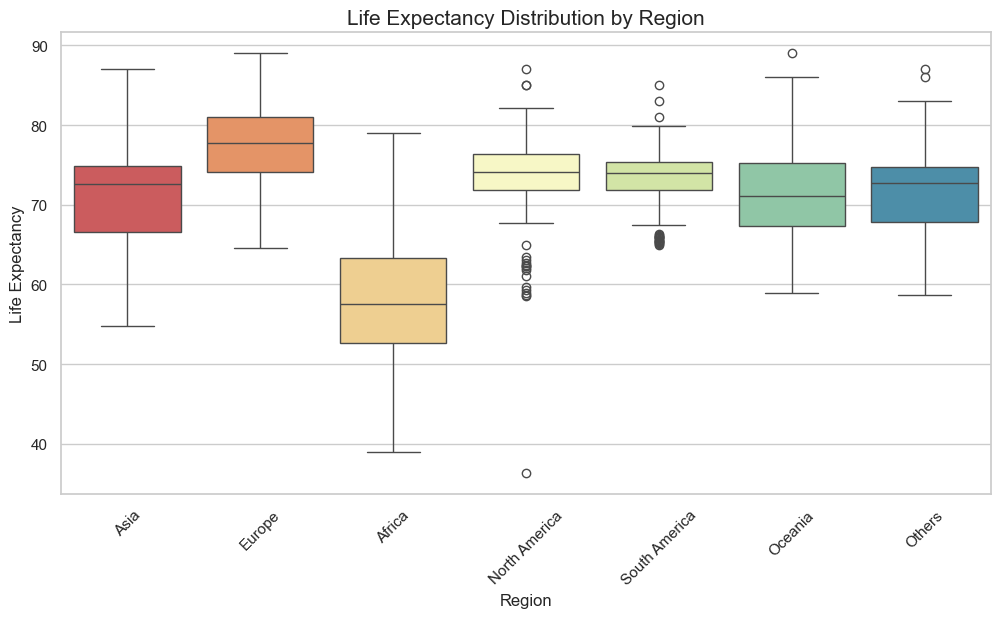

In [255]:
# 시각화 스타일 설정
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Region별 Life expectancy 분포 시각화
sns.boxplot(x='Region', y='Life_expectancy', data=df, palette='Spectral')

plt.title('Life Expectancy Distribution by Region', fontsize=15)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Life Expectancy', fontsize=12)
plt.xticks(rotation=45) # 지역 이름이 겹치면 회전
plt.show()

C:\Users\Moon\AppData\Local\Temp\ipykernel_42416\2413986523.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Region', y='Adult_Mortality', data=df, palette='Spectral')


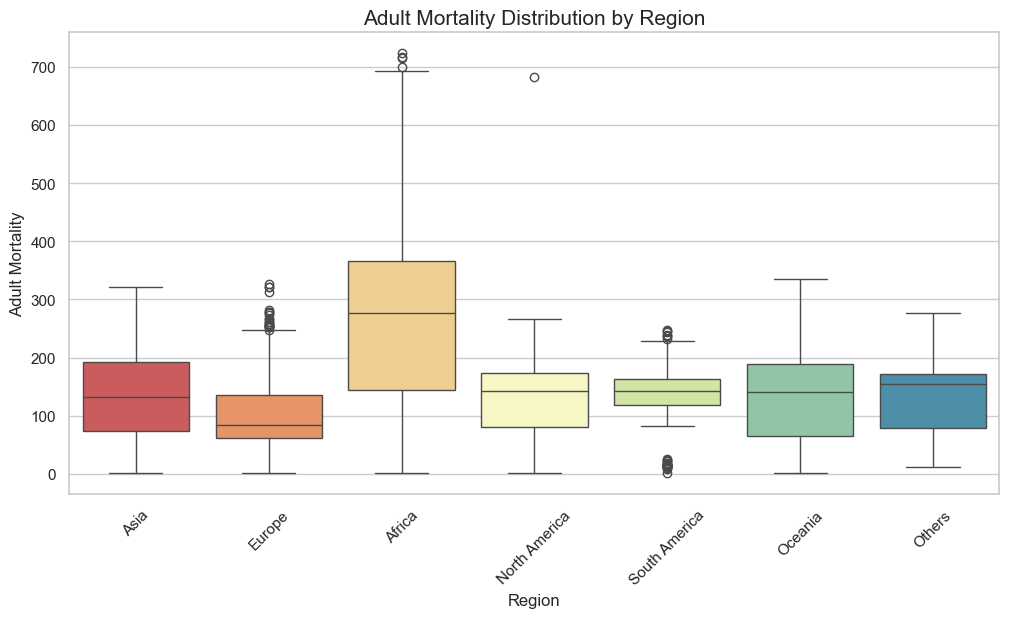

In [256]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

sns.boxplot(x='Region', y='Adult_Mortality', data=df, palette='Spectral')

plt.title('Adult Mortality Distribution by Region', fontsize=15)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Adult Mortality', fontsize=12)
plt.xticks(rotation=45) # 지역 이름이 겹치면 회전
plt.show()